# Differential Expression in Bulk RNA-seq with AnnData

<img 
    src="./assets/header.png" 
    alt="Header for Differential Expression in Bulk RNA-seq with AnnData"
    align="center" 
    style="border: 2px solid #ccc; border-radius: 8px; padding: 5px; width: 100%; box-shadow: 0px 4px 8px rgba(0,0,0,0.1);">

## Introduction

The Cancer Genome Atlas (TCGA) has greatly impacted cancer research by providing comprehensive molecular profiles of over 11,000 tumors across 33 cancer types. This wealth of genomic data enables researchers to identify driver mutations, discover therapeutic targets, and understand the molecular basis of treatment response. However, analyzing TCGA's massive datasets, containing thousands of samples with tens of thousands of genes, can be challenging. This workflow demonstrates how to perform differential expression analysis on TCGA data using modern Python tools and interactive HoloViz visualizations to derive biological insights from sequencing counts.

### Why TCGA Analysis Matters for Cancer Research

Differential expression analysis of TCGA data is fundamental for:
- **Identifying cancer biomarkers** that distinguish tumor from normal tissue
- **Understanding oncogenic pathways** by revealing coordinated gene expression changes
- **Discovering therapeutic vulnerabilities** through identification of overexpressed targetable genes
- **Stratifying patient populations** based on molecular signatures for precision medicine
- **Validating findings** from smaller studies using TCGA's large, well-annotated cohorts

This workflow guides you through a complete analysis pipeline, from loading TCGA breast cancer data to identifying significantly dysregulated genes, using tools that can scale to pan-cancer analyses.


In [1]:
from pathlib import Path
import anndata as ad
import holoviews as hv
import panel as pn
import hvplot.pandas    # noqa
import numpy as np
import pooch
import pydeseq2.dds
import pydeseq2.ds
import scanpy as sc

import hv_anndata
from hv_anndata import ClusterMap

hv_anndata.register()
hv.extension("bokeh")
pn.extension()
pn.config.throttled = True

## Part 1: Loading and Understanding TCGA Data Structure

For this demonstration, we'll analyze TCGA breast cancer (BRCA) samples that have been preprocessed into the AnnData format, commonly used for single-cell and bulk RNA-seq analysis. The dataset has been subsampled to ~120MB for easier demonstration and dissemination of this workflow.

### Understanding the Data Structure

TCGA data in AnnData format contains:
- **Expression matrix (`X`)**: Raw read counts from RNA sequencing
- **Sample metadata (`obs`)**: Clinical and technical annotations for each sample
- **Gene information (`var`)**: Gene symbols, IDs, and annotations
- **Additional matrices (`layers`)**: Normalized counts, log-transformed values, etc.

<div class="admonition alert alert-info">
    <p class="admonition-title" style="font-weight:bold">Data Access Note</p>
    This demonstration uses publicly available TCGA data. For access to full TCGA datasets, visit the <a href="https://portal.gdc.cancer.gov/">GDC Data Portal</a>.
</div>

In [2]:
DATA_URL = 'https://storage.googleapis.com/tcga-anndata-public/test2025-04/brca_test.h5ad'
DATA_DIR = Path('./data')
DATA_FILENAME = Path(DATA_URL).name
DATA_PATH = DATA_DIR / DATA_FILENAME

print(f'Local Data Path: {DATA_PATH}')

Local Data Path: data/brca_test.h5ad


<div class="admonition alert alert-info">
    <p class="admonition-title" style="font-weight:bold">Note</p>
    If you are viewing this notebook as a result of using the `anaconda-project run` command, the data has already been ingested, as configured in the associated yaml file. Running the following cell should find that data and skip any further download.
</div>

<div class="admonition alert alert-warning">
    <p class="admonition-title" style="font-weight:bold">Warning</p>
    If the data was not previously ingested with `anaconda-project`, the following cell will download ~100 MB the first time it is run.
</div>

In [3]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Download the data if it doesn't exist
if not DATA_PATH.exists():
    print(f'Downloading data to: {DATA_PATH}')
    pooch.retrieve(
        path=DATA_DIR,
        fname='brca_test.h5ad',
        url="https://storage.googleapis.com/tcga-anndata-public/test2025-04/brca_test.h5ad",
        known_hash="md5:0e17ecf3716174153bc31988ba6dd161"
    )
    print(f'Dataset downloaded to: {DATA_PATH}')
else:
    print(f'Data exists at: {DATA_PATH}')

Data exists at: data/brca_test.h5ad


In [4]:
adata = ad.read_h5ad(DATA_PATH.resolve())
adata

AnnData object with n_obs × n_vars = 386 × 60664
    obs: 'project_short_name', 'primary_site', 'case_barcode', 'sample_barcode', 'sample_type_name', 'case_gdc_id', 'sample_gdc_id', 'aliquot_gdc_id', 'file_gdc_id', 'platform'
    var: 'gene_name', 'gene_type', 'Ensembl_gene_id'
    obsm: 'clinical'

## Part 2: Cohort Selection and Quality Control

### Exploring Sample Types

TCGA includes multiple sample types from the same patients, enabling paired analyses. Let's examine what sample types are available:


In [5]:
adata.obs.sample_type_name.value_counts()

sample_type_name
Primary Tumor          347
Solid Tissue Normal     37
Metastatic               2
Name: count, dtype: int64

The cell output above should look like the following:
```python
sample_type_name
Primary Tumor          347
Solid Tissue Normal     37
Metastatic               2
Name: count, dtype: int64

```

For differential expression analysis, we'll compare:
- **Primary Tumor**: Cancer tissue from the original tumor site
- **Solid Tissue Normal**: Adjacent normal breast tissue (crucial controls)

We'll exclude metastatic samples due to their small sample size in this subset.


In [6]:
# Define cohort for analysis
sample_types = ["Primary Tumor", "Solid Tissue Normal"]

# Verify tissue origin
adata.obs.primary_site.value_counts()

primary_site
Breast    386
Name: count, dtype: int64

### Data Filtering and Preprocessing

Quality control is essential for reliable differential expression results. We'll:
1. Filter to breast tissue samples only
2. Remove lowly expressed genes (mean count < 50)
3. Convert sparse matrix to dense format for DESeq2

In [7]:
# Select breast cancer samples of interest
brca = adata[(adata.obs.primary_site == "Breast") & 
           (adata.obs.sample_type_name.isin(sample_types))]

# Filter genes with sufficient expression
brca = brca[:, np.mean(brca.X, axis=0) > 50].copy()

# Convert to dense matrix for analysis
brca.X = brca.X.todense()

print(f"Analysis cohort: {brca.n_obs} samples × {brca.n_vars} genes")

Analysis cohort: 384 samples × 17282 genes


/tmp/ipykernel_3591/1932991994.py:9: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  brca.X = brca.X.todense()


<div class="admonition alert alert-info">
    <p class="admonition-title" style="font-weight:bold">Filtering Rationale</p>
    Removing genes with low expression reduces noise and multiple testing burden while preserving biologically relevant signals. The threshold of 50 mean counts is conservative but appropriate for TCGA's sequencing depth.
</div>

## Part 3: Differential Expression Analysis with DESeq2

### Why DESeq2?

DESeq2 is a standard tool for differential expression analysis because it:
- **Models count data appropriately** using negative binomial distribution
- **Normalizes for library size** and RNA composition biases
- **Shrinks log fold changes** for genes with low counts, reducing false positives
- **Provides robust statistical testing** with multiple testing correction

### Running the Analysis


In [8]:
# Create DESeq dataset with experimental design
brca_ds = pydeseq2.dds.DeseqDataSet(
    adata=brca, 
    design="~sample_type_name",  # Compare by sample type
    quiet=True,
    n_cpus=1, # Remove this for multi-cpu processing
)

In [9]:
%%time
# Run differential expression analysis.
# (only when not already in the Panel cache as this is a costly step
# we don't want every app visitor to pay)
if 'brca_ds_deseq2' in pn.state.cache:
    brca_ds = pn.state.cache['brca_ds_deseq2']
else:
    brca_ds.deseq2()
    pn.state.cache['brca_ds_deseq2'] = brca_ds

Fitting dispersions...


... done in 2.82 seconds.

Fitting MAP dispersions...


... done in 2.44 seconds.

Fitting LFCs...


CPU times: user 4min 48s, sys: 491 ms, total: 4min 48s
Wall time: 1min 18s


... done in 1.71 seconds.



The analysis performs several steps:
1. Estimating size factors (normalization)
2. Estimating gene dispersions
3. Fitting the negative binomial model
4. Testing for differential expression
   
### Adding Log-Transformed Counts

For visualization, we'll add log-transformed normalized counts:

In [10]:
# Log transform normalized counts for visualization
brca_ds.layers['log1p'] = np.log1p(brca_ds.layers['normed_counts'])

In [11]:
brca_ds

AnnData object with n_obs × n_vars = 384 × 17282
    obs: 'project_short_name', 'primary_site', 'case_barcode', 'sample_barcode', 'sample_type_name', 'case_gdc_id', 'sample_gdc_id', 'aliquot_gdc_id', 'file_gdc_id', 'platform', 'size_factors', 'replaceable'
    var: 'gene_name', 'gene_type', 'Ensembl_gene_id', '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'clinical', 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks', 'log1p'

## Part 4: Statistical Testing and Visualization

In [12]:
%%time
# Statistical testing: Primary Tumor vs Solid Tissue Normal
t_n = pydeseq2.ds.DeseqStats(
    brca_ds, 
    contrast=["sample_type_name"] + sample_types,
    n_cpus=1, # Remove this for multi-cpu processing
)
t_n.summary()

# Extract results
t_n_res = t_n.results_df

# Merge the gene_name with results
t_n_res = t_n_res.join(brca.var['gene_name'])

Running Wald tests...


Log2 fold change & Wald test p-value: sample_type_name Primary Tumor vs Solid Tissue Normal
                        baseMean  log2FoldChange     lfcSE      stat  \
Ensembl_gene_id_v                                                      
ENSG00000000003.15  3.083404e+03       -0.051624  0.163369 -0.315994   
ENSG00000000005.6   1.318411e+02       -0.879917  0.457697 -1.922488   
ENSG00000000419.13  2.292343e+03       -0.218144  0.100981 -2.160247   
ENSG00000000457.14  1.569745e+03       -0.080183  0.101846 -0.787293   
ENSG00000000460.17  7.200747e+02       -0.068500  0.155700 -0.439949   
...                          ...             ...       ...       ...   
ENSG00000288670.1   4.178192e+02       -0.127817  0.117982 -1.083359   
N_ambiguous         6.307318e+06        0.045140  0.052247  0.863968   
N_multimapping      5.549900e+06        0.053469  0.088378  0.604996   
N_noFeature         3.212396e+06        0.025094  0.103554  0.242329   
N_unmapped          2.969420e+06        0.21

... done in 1.70 seconds.



### Creating a Volcano Plot

Volcano plots are the standard visualization for differential expression results, displaying:
- **X-axis**: Log2 fold change (effect size)
- **Y-axis**: Statistical significance (-log10 adjusted p-value)

In [13]:
# Prepare data for visualization
t_n_res['neg_log10_p'] = -np.log10(t_n_res['pvalue'])
t_n_res['neg_log10_padj'] = -np.log10(t_n_res['padj'])

# Create significance categories based on both thresholds
significance_threshold = -np.log10(0.05)
fold_change_threshold = 1.0

t_n_res['significance'] = 'Not-Significant'
t_n_res.loc[
    (t_n_res['neg_log10_padj'] > significance_threshold) & 
    (abs(t_n_res['log2FoldChange']) > fold_change_threshold), 
    'significance'
] = 'Significant'

volcano_plot = t_n_res.hvplot.scatter(
    x="log2FoldChange", 
    y="neg_log10_padj",
    c='significance',
    cmap={'Not-Significant': 'lightgrey', 'Significant': 'black'},
    hover_cols=['gene_name', 'significance'],
    title="Differential Expression: Tumor vs Normal",
    legend='top_right',
    alpha=0.6,
    size=20,
    responsive=True,
    height=500
)

# Add threshold lines
(
    volcano_plot
    * hv.HLine(significance_threshold).opts(color='red', line_dash='dashed', line_width=2)
    * hv.VLine(-fold_change_threshold).opts(color='blue', line_dash='dashed', line_width=2) 
    * hv.VLine(fold_change_threshold).opts(color='blue', line_dash='dashed', line_width=2)
)

:Overlay
   .Scatter.I :Scatter   [log2FoldChange]   (neg_log10_padj,significance,gene_name)
   .HLine.I   :HLine   [x,y]
   .VLine.I   :VLine   [x,y]
   .VLine.II  :VLine   [x,y]

---
<img 
    src="./assets/volcano.png"   
    alt="Volcano plot showing differentially expressed genes" 
    align="right" 
    width="75%">

**Static preview of the above plot. The Interactive volcano plot reveals significantly differentially expressed genes in breast cancer. Red line: p-adj = 0.05; Blue lines: |log2FC| = 1 👉**

<div style="clear: both;"></div>

---

### Identifying Significantly Dysregulated Genes

In [14]:
# Select genes with adjusted p-value < 0.05 and |log2FC| > 1
sig_genes = t_n_res[
    (t_n_res['neg_log10_padj'] > significance_threshold) & 
    (abs(t_n_res['log2FoldChange']) > fold_change_threshold)
]

# Store Ensembl IDs before changing index
sig_genes['ensembl_id'] = sig_genes.index

# Set gene_name as index for better display
sig_genes = sig_genes.set_index('gene_name')
    
print(f"Found {len(sig_genes)} significantly dysregulated genes")
print("\nTop upregulated in tumor:")
print(sig_genes.nlargest(5, 'log2FoldChange')[['log2FoldChange', 'padj', 'ensembl_id']])
print("\nTop downregulated in tumor:")
print(sig_genes.nsmallest(5, 'log2FoldChange')[['log2FoldChange', 'padj', 'ensembl_id']])

Found 275 significantly dysregulated genes

Top upregulated in tumor:
            log2FoldChange          padj         ensembl_id
gene_name                                                  
RNU1-88P         11.274214  3.592269e-03  ENSG00000238554.1
MUC2              5.295142  4.022474e-12  ENSG00000198788.9
CST5              4.651614  1.672168e-07  ENSG00000170367.5
RNU1-56P          4.614913  4.944282e-03  ENSG00000212605.1
AC013457.1        4.568986  5.869424e-04  ENSG00000259094.1

Top downregulated in tumor:
            log2FoldChange          padj          ensembl_id
gene_name                                                   
CELF3            -3.247095  4.161569e-14  ENSG00000159409.15
NPY2R            -3.021683  3.845819e-03   ENSG00000185149.6
AC104407.1       -2.891640  1.422017e-02   ENSG00000250538.6
CDH7             -1.812111  2.101568e-02  ENSG00000081138.14
TSPAN8           -1.791027  1.098049e-02   ENSG00000127324.9


/tmp/ipykernel_3591/77719896.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig_genes['ensembl_id'] = sig_genes.index


## Part 5: Expression Heatmap with Hierarchical Clustering

To visualize expression patterns across samples, we'll create a clustered heatmap of significantly dysregulated genes. This reveals:
- **Co-expression modules** of functionally related genes
- **Sample clustering** that may identify molecular subtypes
- **Quality control** by confirming tumor/normal separation

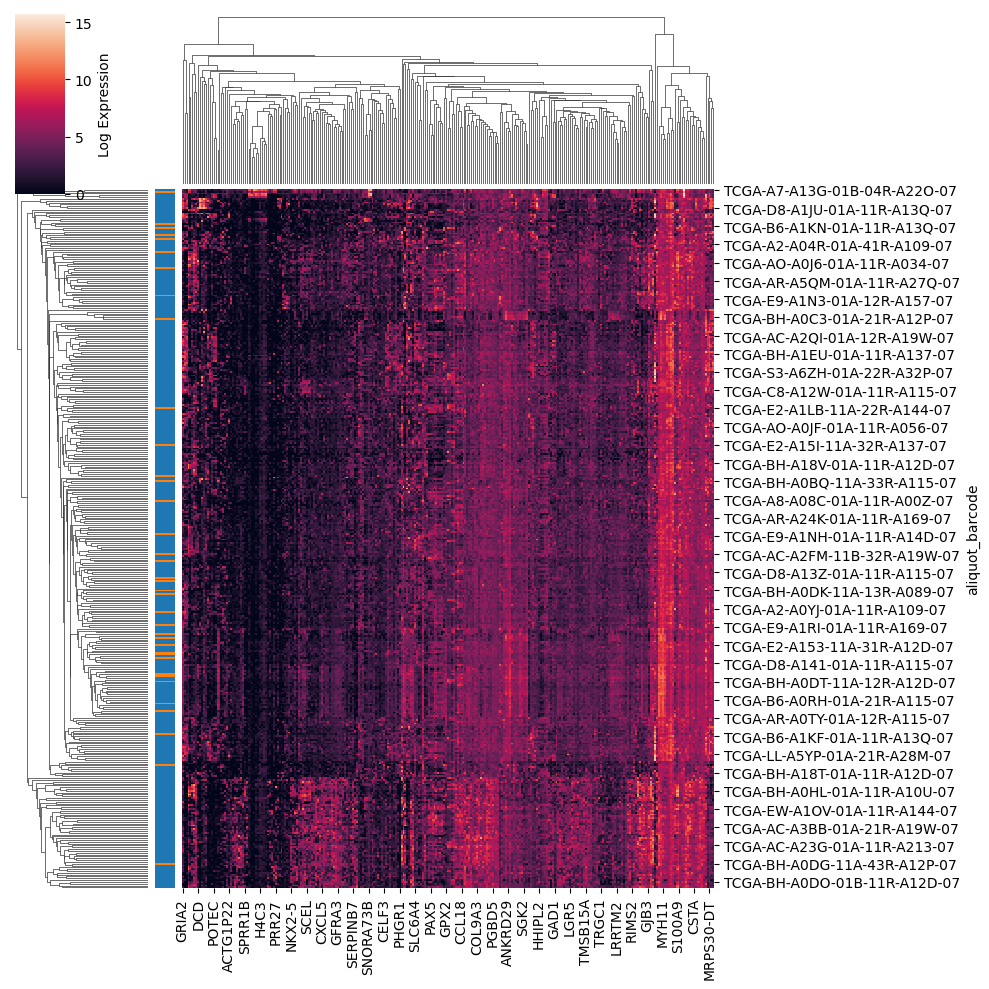

In [15]:
# Log transform for visualization
brca_log1p = brca.copy()
brca_log1p.X = np.log1p(brca_log1p.X)

# Select significant genes using Ensembl IDs
sig_ensembl_ids = sig_genes['ensembl_id'].values
brca_sig = brca_log1p[:, sig_ensembl_ids].copy()

# Update the var names to use gene symbols for better visualization
if 'gene_name' in brca.var.columns:
    # Create a mapping from Ensembl ID to gene name
    id_to_name = dict(zip(sig_genes['ensembl_id'], sig_genes.index))
    
    # Update var_names in the subset
    new_var_names = [id_to_name.get(eid, eid) for eid in brca_sig.var_names]
    brca_sig.var_names = new_var_names


# Create clustered heatmap using scanpy
sc.pl.clustermap(
    brca_sig, 
    obs_keys='sample_type_name',  # Colored bar showing tumor vs normal
    use_raw=False,  # Use the log-transformed values
    figsize=(10, 10),  # Passed to seaborn
    cbar_kws={'label': 'Log Expression'}  # Passed to seaborn
)


## Toward Interactive Exploration with HoloViz

These limitations of a static plot underscore the need for interactive visualization tools in genomic analysis. The HoloViz ecosystem is developing an interactive ClusterMap. It currently enables:
- **Zoom and pan** to explore specific regions while maintaining context
- **Hover tooltips** showing gene names, sample IDs, and exact expression values

In the future, it will support:
- **Dynamic filtering** to focus on specific gene sets or sample subgroups
- **Adjoined Bars** to indicate additional features of each sample (like showing tumor vs normal) or gene

In [16]:
ClusterMap(adata=brca_sig, plot_opts={'width': 700, 'height':700}).servable() # servable for Panel standalone apps

Row(design=<class 'panel_material_ui...., objects=[Column(design=<class 'pan...])

---
<img 
    src="./assets/clustermap.png"  
    alt="Clustered heatmap of differentially expressed genes" 
    align="right" 
    width="75%"> 

**Static preview of the above cell output. The hierarchical clustering reveals expression patterns along interactive capabilities 👉**

<div style="clear: both;"></div>

---


<div class="admonition alert alert-info">
    <p class="admonition-title" style="font-weight:bold">Next Steps</p>
    Consider pathway enrichment analysis on significant genes using tools like <a href="http://www.gsea-msigdb.org/gsea/index.jsp">GSEA</a> or <a href="https://maayanlab.cloud/Enrichr/">Enrichr</a> to understand biological processes driving the expression changes.
</div>


## Clinical Applications

This differential expression workflow underpins biomarker discovery, therapeutic target identification, and molecular subtyping. It enables researchers to identify diagnostic and prognostic genes, uncover druggable vulnerabilities, and define expression signatures that stratify patients and predict treatment response, providing a foundation for precision oncology.


## Acknowledgments

This workflow was developed with support from NIH-NCI. TCGA data is provided by the National Cancer Institute Genomic Data Commons.